In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist

In [2]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 6,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33037,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46761,Total threads: 3
Dashboard: http://127.0.0.1:45257/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:35607,


2025-08-20 15:20:23,628 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('open_dataset-lon-117fdc276c2abab5febb541f7260f64e', 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('open_dataset-lon-117fdc276c2abab5febb541f7260f64e', 0, 0)->('original-open_dataset-lon-117fdc276c2abab5febb541f7260f64e', 0, 0))
new run_spec: <Task ('open_dataset-lon-117fdc276c2abab5febb541f7260f64e', 0, 0) getter(...)>
old dependencies: {('original-open_dataset-lon-117fdc276c2abab5febb541f7260f64e', 0, 0)}
new dependencies: frozenset({'original-open_dataset-lon-117fdc276c2abab5febb541f7260f64e'})

2025-08-20 15

In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
stores = sorted(Path("/work/bk1450/b383184/Amazon/Atlantic/data/tracks_3456").glob("Parcels_run_*_*.zarr"))
stores[:3]

[PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_3456/Parcels_run_3456_2022-06-05T00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_3456/Parcels_run_3456_2022-06-10T00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_3456/Parcels_run_3456_2022-06-15T00:00:00.zarr')]

In [5]:
ds_list = [xr.open_zarr(s) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

ds

<xarray.Dataset> Size: 36GB
Dimensions:     (trajectory: 1940000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 16MB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 14GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [6]:
num_valid_obs_steps = int(ds.lat.notnull().any('trajectory').sum().compute().data[()])
ds = ds.isel(obs=slice(None, num_valid_obs_steps))
ds

<xarray.Dataset> Size: 29GB
Dimensions:     (trajectory: 1940000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 16MB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 12GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [7]:
ds = ds.assign(start_time=ds.time.isel(obs=0).compute())
ds = ds.assign(start_year=ds.start_time.dt.year)
ds = ds.assign(start_month=ds.start_time.dt.month)
ds

<xarray.Dataset> Size: 29GB
Dimensions:      (trajectory: 1940000, obs: 741)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory   (trajectory) int64 16MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat          (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon          (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 12GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z            (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_time   (trajectory) datetime64[ns] 16MB 2022-06-05 ... 2025-06-05
    start_year   (trajectory) int64 16MB 2022 2022 2022 2022 ... 2025 2025 2025
    start_month  (trajectory) int64 16MB 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [8]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

In [32]:
import matplotlib.pyplot as plt
import numpy as np

In [30]:
ds = ds.assign_coords(start_time=ds.start_time.astype('datetime64[ns]'))
# start_date = ds.start_time.dt.floor('D')  # or .dt.normalize()
# start_date
ds

<xarray.Dataset> Size: 29GB
Dimensions:      (trajectory: 1940000, obs: 741)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory   (trajectory) int64 16MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
    start_time   (trajectory) datetime64[ns] 16MB 2022-06-05 ... 2025-06-05
Data variables:
    lat          (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon          (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 12GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z            (trajectory, obs) float32 6GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_year   (trajectory) int64 16MB 2022 2022 2022 2022 ... 2025 2025 2025
    start_month  (trajectory) int64 16MB 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

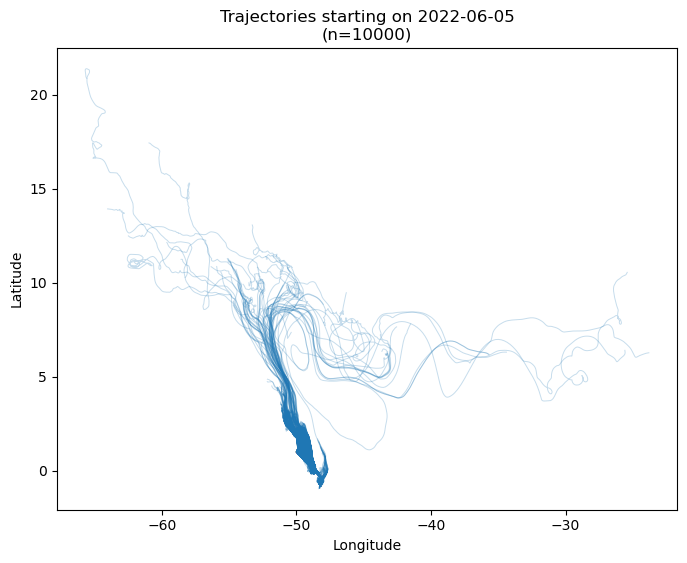

In [36]:
# pick the day you want
target_date = np.datetime64('2022-06-05')  # change me

# select only trajectories starting on that day
mask = ds.start_time.dt.floor('D') == target_date
ds_day = ds.isel(trajectory=mask)

# pull lon/lat to memory only for this day
lon = ds_day.lon.compute().values   # shape (n_traj, n_obs)
lat = ds_day.lat.compute().values

fig, ax = plt.subplots(figsize=(8, 6))
# quick-and-simple line plot; for many trajectories consider alpha for overplotting
for i in range(lon.shape[0]):
    xi = lon[i]
    yi = lat[i]
    m = np.isfinite(xi) & np.isfinite(yi)
    if m.any():
        ax.plot(xi[m], yi[m], lw=0.7, alpha=0.25, color='tab:blue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Trajectories starting on {np.datetime_as_string(target_date, unit="D")}\n(n={lon.shape[0]})')
plt.show()

### Calculate the Histogram

In [ ]:
import numpy as np

lat_bins = np.linspace(lat_min,lat_max,30)
lon_bins = np.linspace(lon_min,lon_max,30)

def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

In [ ]:
# calc hist for each start year / start month
hist = ds.groupby(["start_year", "start_month"]).apply(calc_hist)

# aggregate obs into 5 day bins (with 4 steps each day), skipping the initial positions
hist = hist.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

# compute and store to file
hist.drop_encoding().compute().to_netcdf("_hist5days.nc")


In [41]:
# reload
hist = xr.open_dataset("_hist.nc").compute().histogram_lon_lat
hist

<xarray.DataArray 'histogram_lon_lat' (obs: 37, lon: 29, lat: 29,
                                       start_year: 4, start_month: 12)> Size: 12MB
array([[[[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

         [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

         [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

         ...,

         [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
...
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

         ...,

         [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

         [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

         [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]]]]],
      shape=(37, 29, 29, 4, 12))
Coordinates:
  * start_year   (start_year) int64 32B 2022 2023 2024 2025
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float32 116B -88.2 -85.11 -82.01 ... -7.737 -4.642 -1.548
  * lat          (lat) float32 116B -5.438 -4.227 -3.016 ... 26.05 27.26 28.47

In [42]:
from matplotlib import pyplot as plt
import cartopy

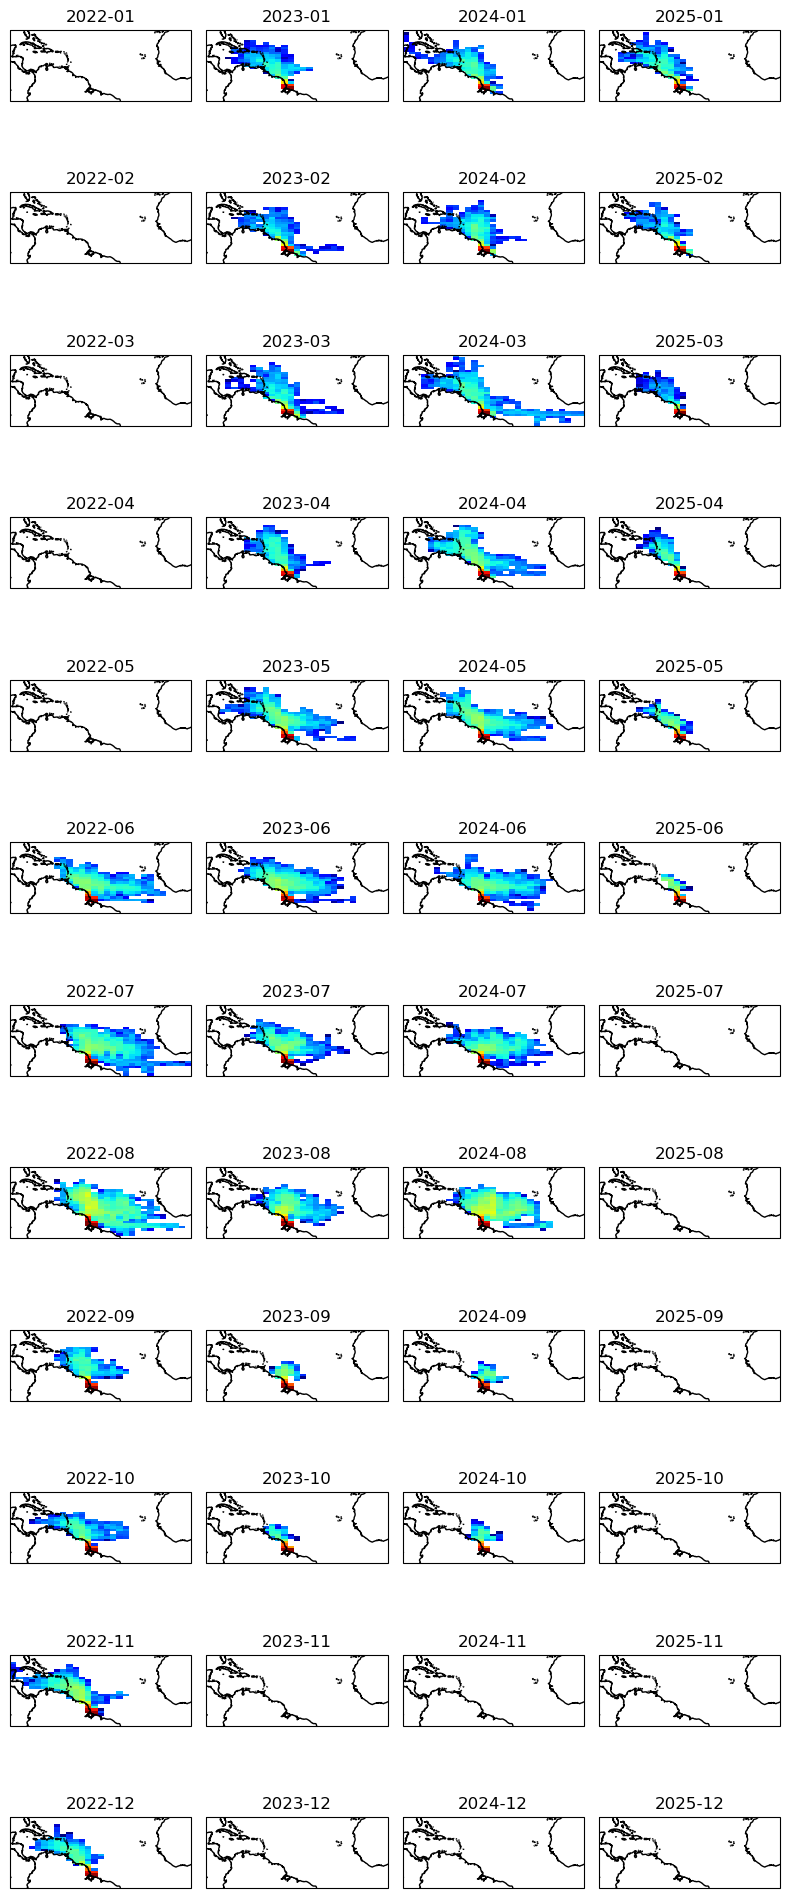

In [46]:
fig, ax = plt.subplots(
    len(np.unique(hist.start_month.data)),
    len(np.unique(hist.start_year.data)),
    figsize=(8, 20),
    subplot_kw={"projection": cartopy.crs.PlateCarree()},
)

np.seterr(divide = 'ignore')  # Don't warn on np.log10 on invalid or 0 data
for nyr, syr in enumerate(sorted(np.unique(hist.start_year.data))):
    for nmon, smon  in enumerate(sorted(np.unique(hist.start_month.data))):
        _ax = ax[nmon, nyr]
        np.log10(hist.sel(start_year=syr, start_month=smon).sum("obs")).plot(
            x="lon", y="lat", 
            transform=cartopy.crs.PlateCarree(), ax=_ax,
            add_colorbar=False, cmap='jet'
        )
        _ax.set_title(f"{syr:04d}-{smon:02d}")
        _ax.coastlines();
fig.tight_layout();

In [47]:
# helper to build alpha from hist slice
def make_alpha(H2):
    # use log scale but avoid -inf
    with np.errstate(divide='ignore', invalid='ignore'):
        L = np.log10(H2)
    L = L.where(np.isfinite(L), other=np.nan)
    # rescale per panel to [0,1]
    vmax = float(L.max().values) if np.isfinite(L.max()).item() else 0.0
    vmin = float(L.min().values) if np.isfinite(L.min()).item() else 0.0
    if vmax > vmin:
        A = (L - vmin) / (vmax - vmin)
    else:
        A = xr.zeros_like(L)
    # optional gamma to enhance low counts
    A = A.fillna(0.0) ** 0.7
    return A


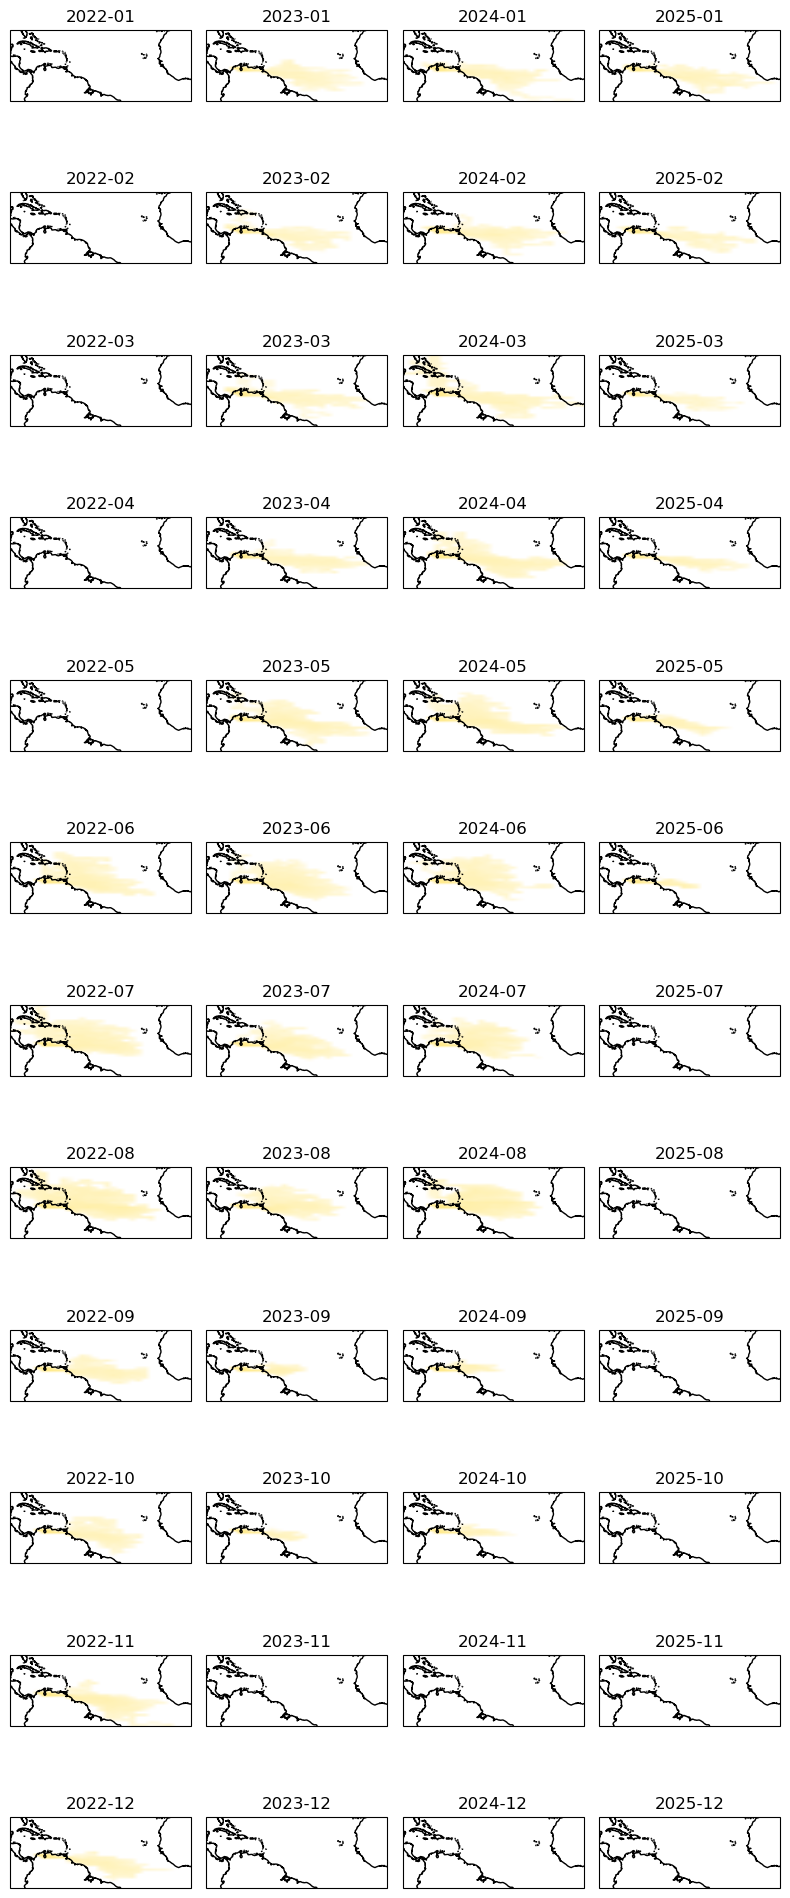

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# panels: month x year (as you have)
years  = sorted(np.unique(hist.start_year.data))
months = sorted(np.unique(hist.start_month.data))

fig, ax = plt.subplots(
    len(months), len(years),
    figsize=(8, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for c, syr in enumerate(years):
    for r, smon in enumerate(months):
        _ax = ax[r, c] if ax.ndim == 2 else ax[max(r, c)]
        # 1) 2D intensity
        H2 = hist.sel(start_year=syr, start_month=smon).sum("obs")  # dims: lon, lat

        # 2) alpha field from log10
        A = make_alpha(H2)

        # 3) draw yellow tile with alpha
        # build RGBA once per panel using xarray coords for extent
        A_np = A.transpose("lon", "lat").values  # (nx, ny)
        xmin = float(H2.lon.min()); xmax = float(H2.lon.max())
        ymin = float(H2.lat.min()); ymax = float(H2.lat.max())

        # constant yellow with varying alpha
        rgba = np.zeros((A_np.shape[0], A_np.shape[1], 4), dtype=float)
        rgba[..., 0] = 1.00  # R
        rgba[..., 1] = 0.85  # G
        rgba[..., 2] = 0.15  # B
        rgba[..., 3] = 0.55 * A_np  # tweak 0.55 for strength

        _ax.imshow(
            rgba,
            extent=[xmin, xmax, ymin, ymax],
            origin="lower",
            interpolation="bilinear",   # or 'bilinear' for softer look
            transform=ccrs.PlateCarree(),
            zorder=1,
        )

        # optional: contour lines over the shadow (example using the same H2)
        # H2.T.plot.contour(x="lon", y="lat", colors="k", levels=10, add_colorbar=False, ax=_ax)

        _ax.set_title(f"{syr:04d}-{smon:02d}")
        _ax.coastlines()
        _ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())

fig.tight_layout()

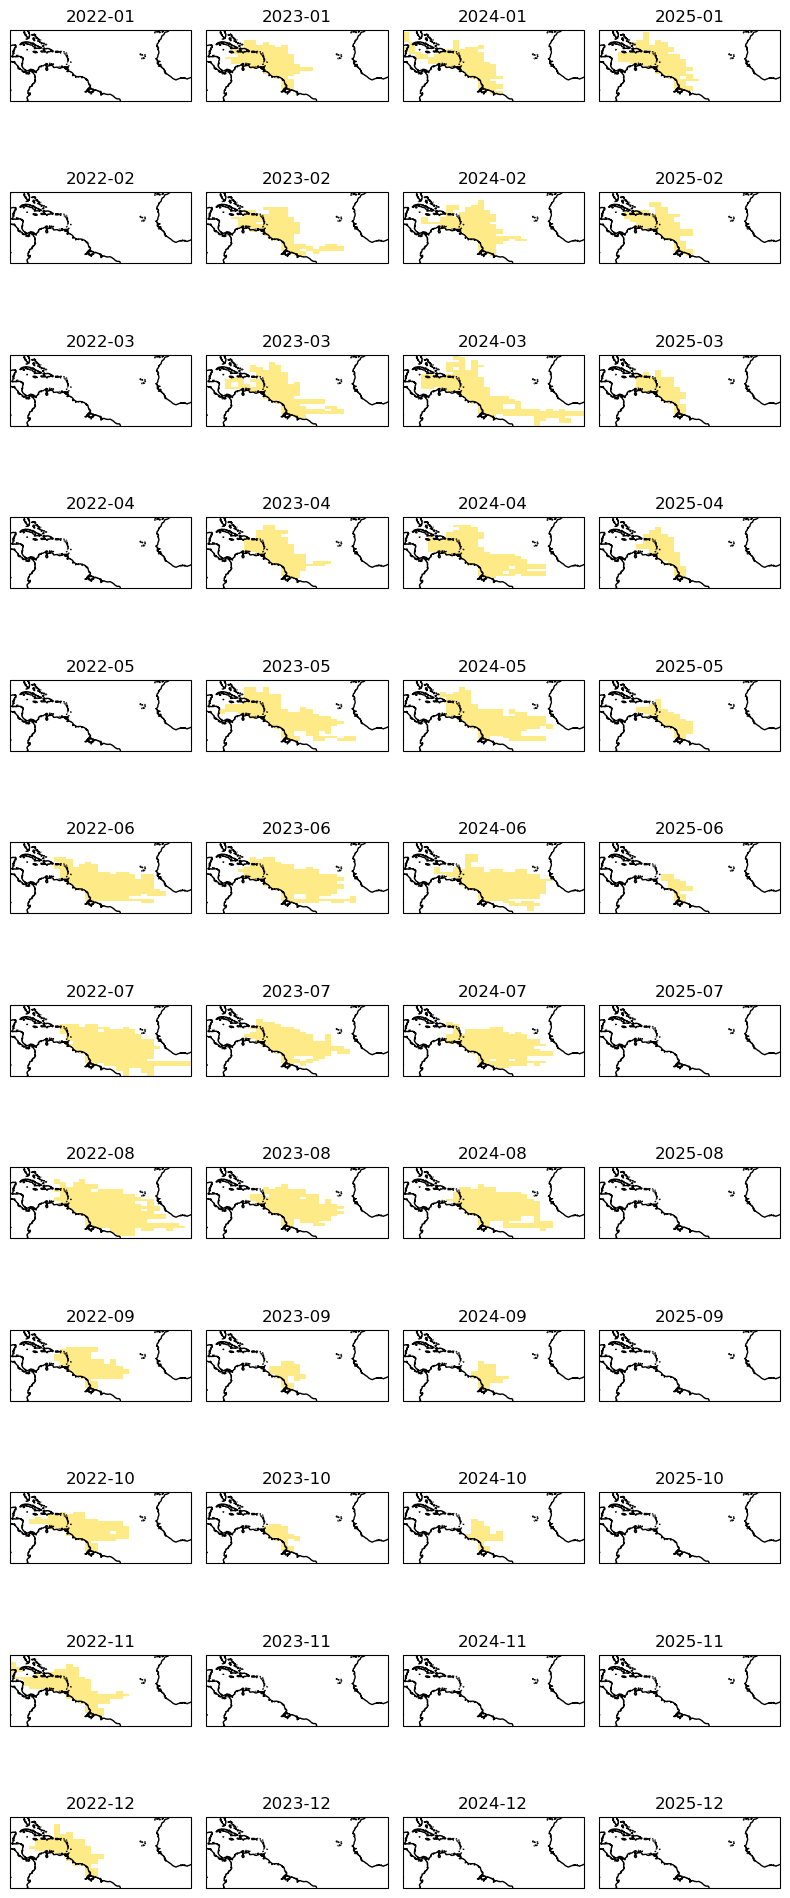

In [49]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

years  = sorted(np.unique(hist.start_year.data))
months = sorted(np.unique(hist.start_month.data))

yellow = (1.0, 0.85, 0.15, 1.0)          # solid yellow
cmap   = mcolors.ListedColormap([yellow])
alpha_val = 0.55                          # uniform opacity

fig, ax = plt.subplots(len(months), len(years),
                       figsize=(8, 20),
                       subplot_kw={"projection": ccrs.PlateCarree()})

for c, syr in enumerate(years):
    for r, smon in enumerate(months):
        _ax = ax[r, c]

        # collapse obs and build a boolean mask of where to paint
        H2 = hist.sel(start_year=syr, start_month=smon).sum("obs")  # lon x lat
        mask = (H2 > 0).transpose("lon", "lat")                     # True where we paint

        # Make a 0/1 array for pcolormesh (1=paint, 0=transparent via alpha mask)
        Z = xr.where(mask, 1, np.nan)  # NaNs won't draw

        # Draw plain yellow
        Z.plot.pcolormesh(
            x="lon", y="lat",
            cmap=cmap, vmin=0, vmax=1,
            add_colorbar=False,
            alpha=alpha_val,
            ax=_ax, transform=ccrs.PlateCarree()
        )

        _ax.coastlines()
        _ax.set_title(f"{syr:04d}-{smon:02d}")

plt.tight_layout()

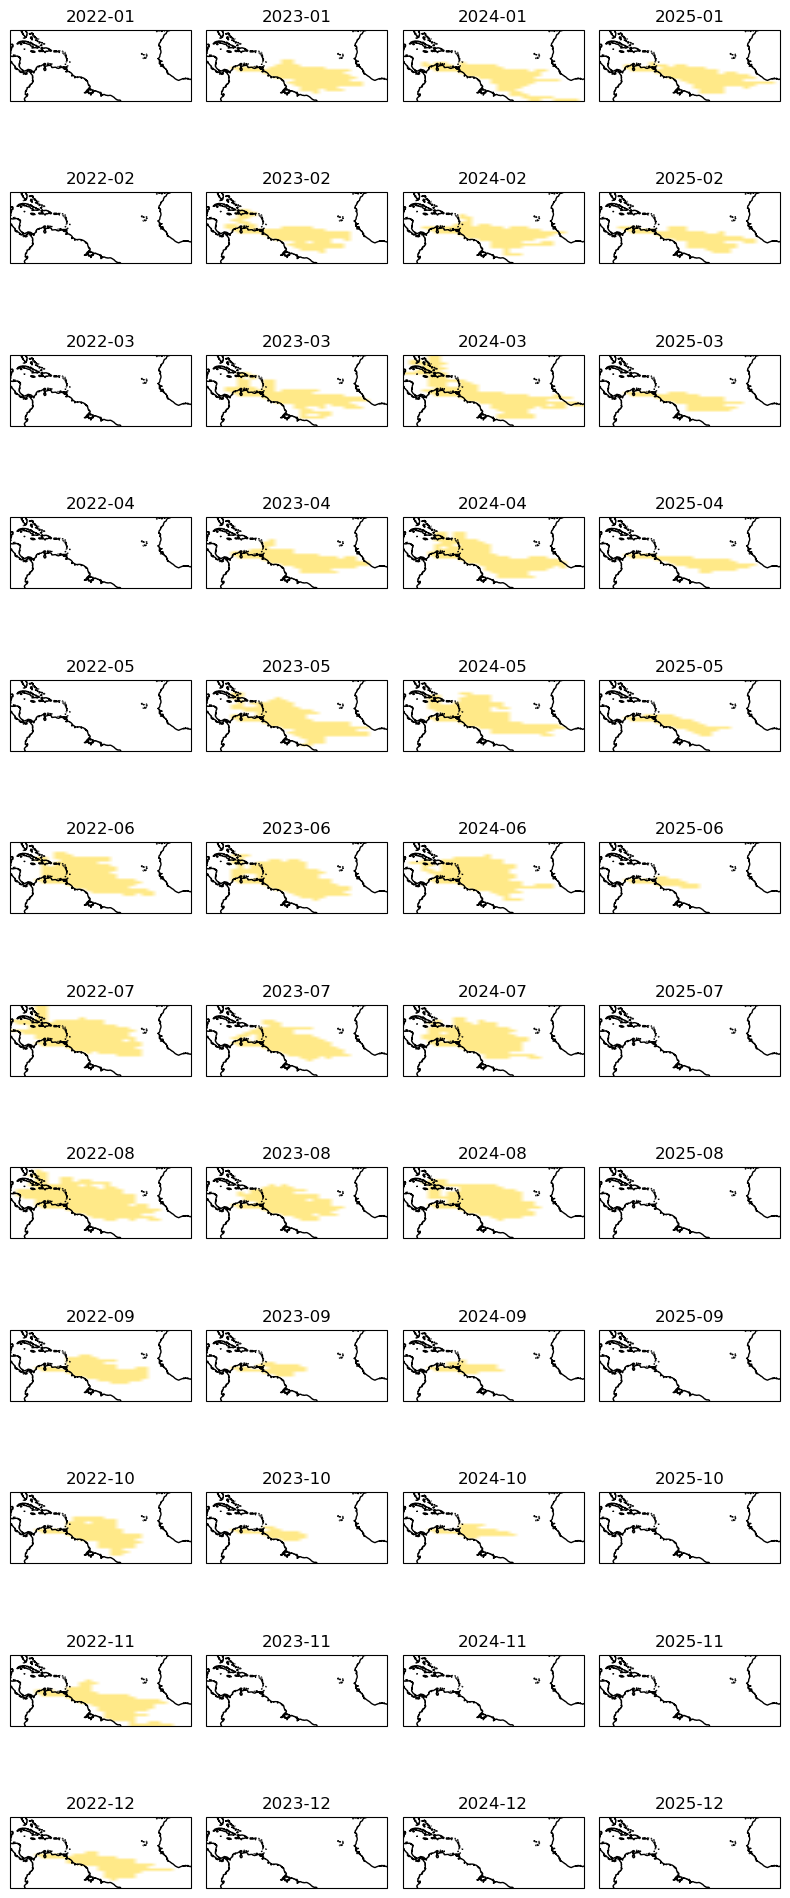

In [52]:
years  = sorted(np.unique(hist.start_year.data))
months = sorted(np.unique(hist.start_month.data))

yellow = (1.0, 0.85, 0.15, 1.0)          # solid yellow
cmap   = mcolors.ListedColormap([yellow])
alpha_val = 0.55                          # uniform opacity

fig, ax = plt.subplots(len(months), len(years),
                       figsize=(8, 20),
                       subplot_kw={"projection": ccrs.PlateCarree()})

for c, syr in enumerate(years):
    for r, smon in enumerate(months):
        _ax = ax[r, c]
        H2 = hist.sel(start_year=syr, start_month=smon).sum("obs")
        m = (H2 > 0).transpose("lon", "lat").values

        # RGBA tile: constant yellow, transparent where mask is False
        rgba = np.zeros((m.shape[0], m.shape[1], 4), dtype=float)
        rgba[..., 0] = 1.00
        rgba[..., 1] = 0.85
        rgba[..., 2] = 0.15
        rgba[..., 3] = 0.55 * m.astype(float)

        xmin = float(H2.lon.min()); xmax = float(H2.lon.max())
        ymin = float(H2.lat.min()); ymax = float(H2.lat.max())

        _ax.imshow(
            rgba, origin="lower",
            extent=[xmin, xmax, ymin, ymax],
            interpolation="bilinear",
            transform=ccrs.PlateCarree(),
            zorder=1
        )
        _ax.coastlines()
        _ax.set_title(f"{syr:04d}-{smon:02d}")

plt.tight_layout()